# 07 - Shortcut diagnostic

Mục tiêu là kiểm tra một classifier rất đơn giản có thể phân biệt Real/Fake chỉ từ các đặc trưng file/ảnh hay không. Logistic Regression chỉ được fit trên 1.600 ảnh train; scaler cũng chỉ fit trên train. Validation gồm 400 ảnh cùng split Week 2.

Diagnostic này không thay thế detector DINOv3/TinyCNN và không chứng minh model chính đang dùng shortcut; nó chỉ cho biết các tín hiệu đơn giản tự chúng có khả năng dự đoán nhãn hay không. Notebook chạy được trên CPU, không cần GPU.

In [1]:
from pathlib import Path
import sys

local_candidates = [Path.cwd(), Path.cwd().parent, Path('/Users/nguyentran0703/Downloads/FaceTrace')]
REPO_DIR = Path('/kaggle/working/FaceTrace') if Path('/kaggle/working/FaceTrace').is_dir() else next((p for p in local_candidates if (p / 'outputs/splits').is_dir()), Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

# Local run uses the locked manifests. On Kaggle, attach the Phase 4 cache or repo snapshot.
local_pair = (REPO_DIR / 'outputs/splits/train.csv', REPO_DIR / 'outputs/splits/val.csv')
if all(path.is_file() for path in local_pair):
    TRAIN_MANIFEST, VAL_MANIFEST = local_pair
    IMAGE_PATH_BASE = REPO_DIR
else:
    input_root = Path('/kaggle/input')
    pairs = []
    for train_manifest in sorted(input_root.rglob('train.csv')):
        val_manifest = train_manifest.with_name('val.csv')
        if val_manifest.is_file():
            pairs.append((train_manifest, val_manifest))
    if len(pairs) != 1:
        raise RuntimeError(f'Expected one train.csv/val.csv pair, found: {pairs}')
    TRAIN_MANIFEST, VAL_MANIFEST = pairs[0]
    # The resolver uses original_path under DATA_ROOT/train/images.
    manifest_candidates = sorted(input_root.rglob('manifest.csv'))
    if not manifest_candidates:
        raise FileNotFoundError('Attach the Who Is AI dataset containing train/manifest.csv.')
    IMAGE_PATH_BASE = manifest_candidates[0].parent.parent

OUTPUT_DIR = REPO_DIR / 'outputs/week03_shortcut_diagnostic'
print('Train manifest:', TRAIN_MANIFEST)
print('Validation manifest:', VAL_MANIFEST)
print('Image base:', IMAGE_PATH_BASE)
print('Output:', OUTPUT_DIR)

Train manifest: /Users/nguyentran0703/Downloads/FaceTrace/outputs/splits/train.csv
Validation manifest: /Users/nguyentran0703/Downloads/FaceTrace/outputs/splits/val.csv
Image base: /Users/nguyentran0703/Downloads/FaceTrace
Output: /Users/nguyentran0703/Downloads/FaceTrace/outputs/week03_shortcut_diagnostic


In [2]:
from src.evaluation.shortcut import run_shortcut_diagnostic

result = run_shortcut_diagnostic(
    train_manifest=TRAIN_MANIFEST,
    validation_manifest=VAL_MANIFEST,
    image_path_base=IMAGE_PATH_BASE,
    output_dir=OUTPUT_DIR,
    threshold=0.5,
)
print(result)

{'metrics': [{'model': 'file_size_only', 'split': 'train', 'balanced_accuracy': 0.63625, 'accuracy': 0.63625, 'f1': 0.6307106598984772, 'auroc': 0.6980429687499999}, {'model': 'file_size_only', 'split': 'val', 'balanced_accuracy': 0.625, 'accuracy': 0.625, 'f1': 0.6212121212121212, 'auroc': 0.684425}, {'model': 'simple_features', 'split': 'train', 'balanced_accuracy': 0.6925, 'accuracy': 0.6925, 'f1': 0.6940298507462687, 'auroc': 0.7610359375}, {'model': 'simple_features', 'split': 'val', 'balanced_accuracy': 0.6775, 'accuracy': 0.6775, 'f1': 0.683046683046683, 'auroc': 0.740325}], 'output_dir': '/Users/nguyentran0703/Downloads/FaceTrace/outputs/week03_shortcut_diagnostic', 'n_train': 1600, 'n_validation': 400}


In [3]:
import pandas as pd

metrics = pd.read_csv(OUTPUT_DIR / 'metrics.csv')
coefficients = pd.read_csv(OUTPUT_DIR / 'coefficients.csv')
display(metrics)
display(coefficients)

,model,split,balanced_accuracy,accuracy,f1,auroc
0,file_size_only,train,0.63625,0.63625,0.630711,0.698043
1,file_size_only,val,0.62500,0.62500,0.621212,0.684425
2,simple_features,train,0.69250,0.69250,0.694030,0.761036
3,simple_features,val,0.67750,0.67750,0.683047,0.740325


,model,feature,standardized_coefficient,odds_ratio_per_standard_deviation
0,file_size_only,log_file_size_bytes,-0.812640,0.443685
1,simple_features,log_file_size_bytes,-0.147569,0.862803
2,simple_features,mean_luminance,0.055955,1.057550
3,simple_features,std_luminance,-0.338049,0.713160
4,simple_features,mean_saturation,-0.562509,0.569778
5,simple_features,gray_pixel_fraction,-0.559094,0.571727
6,simple_features,edge_mean,-0.858298,0.423883


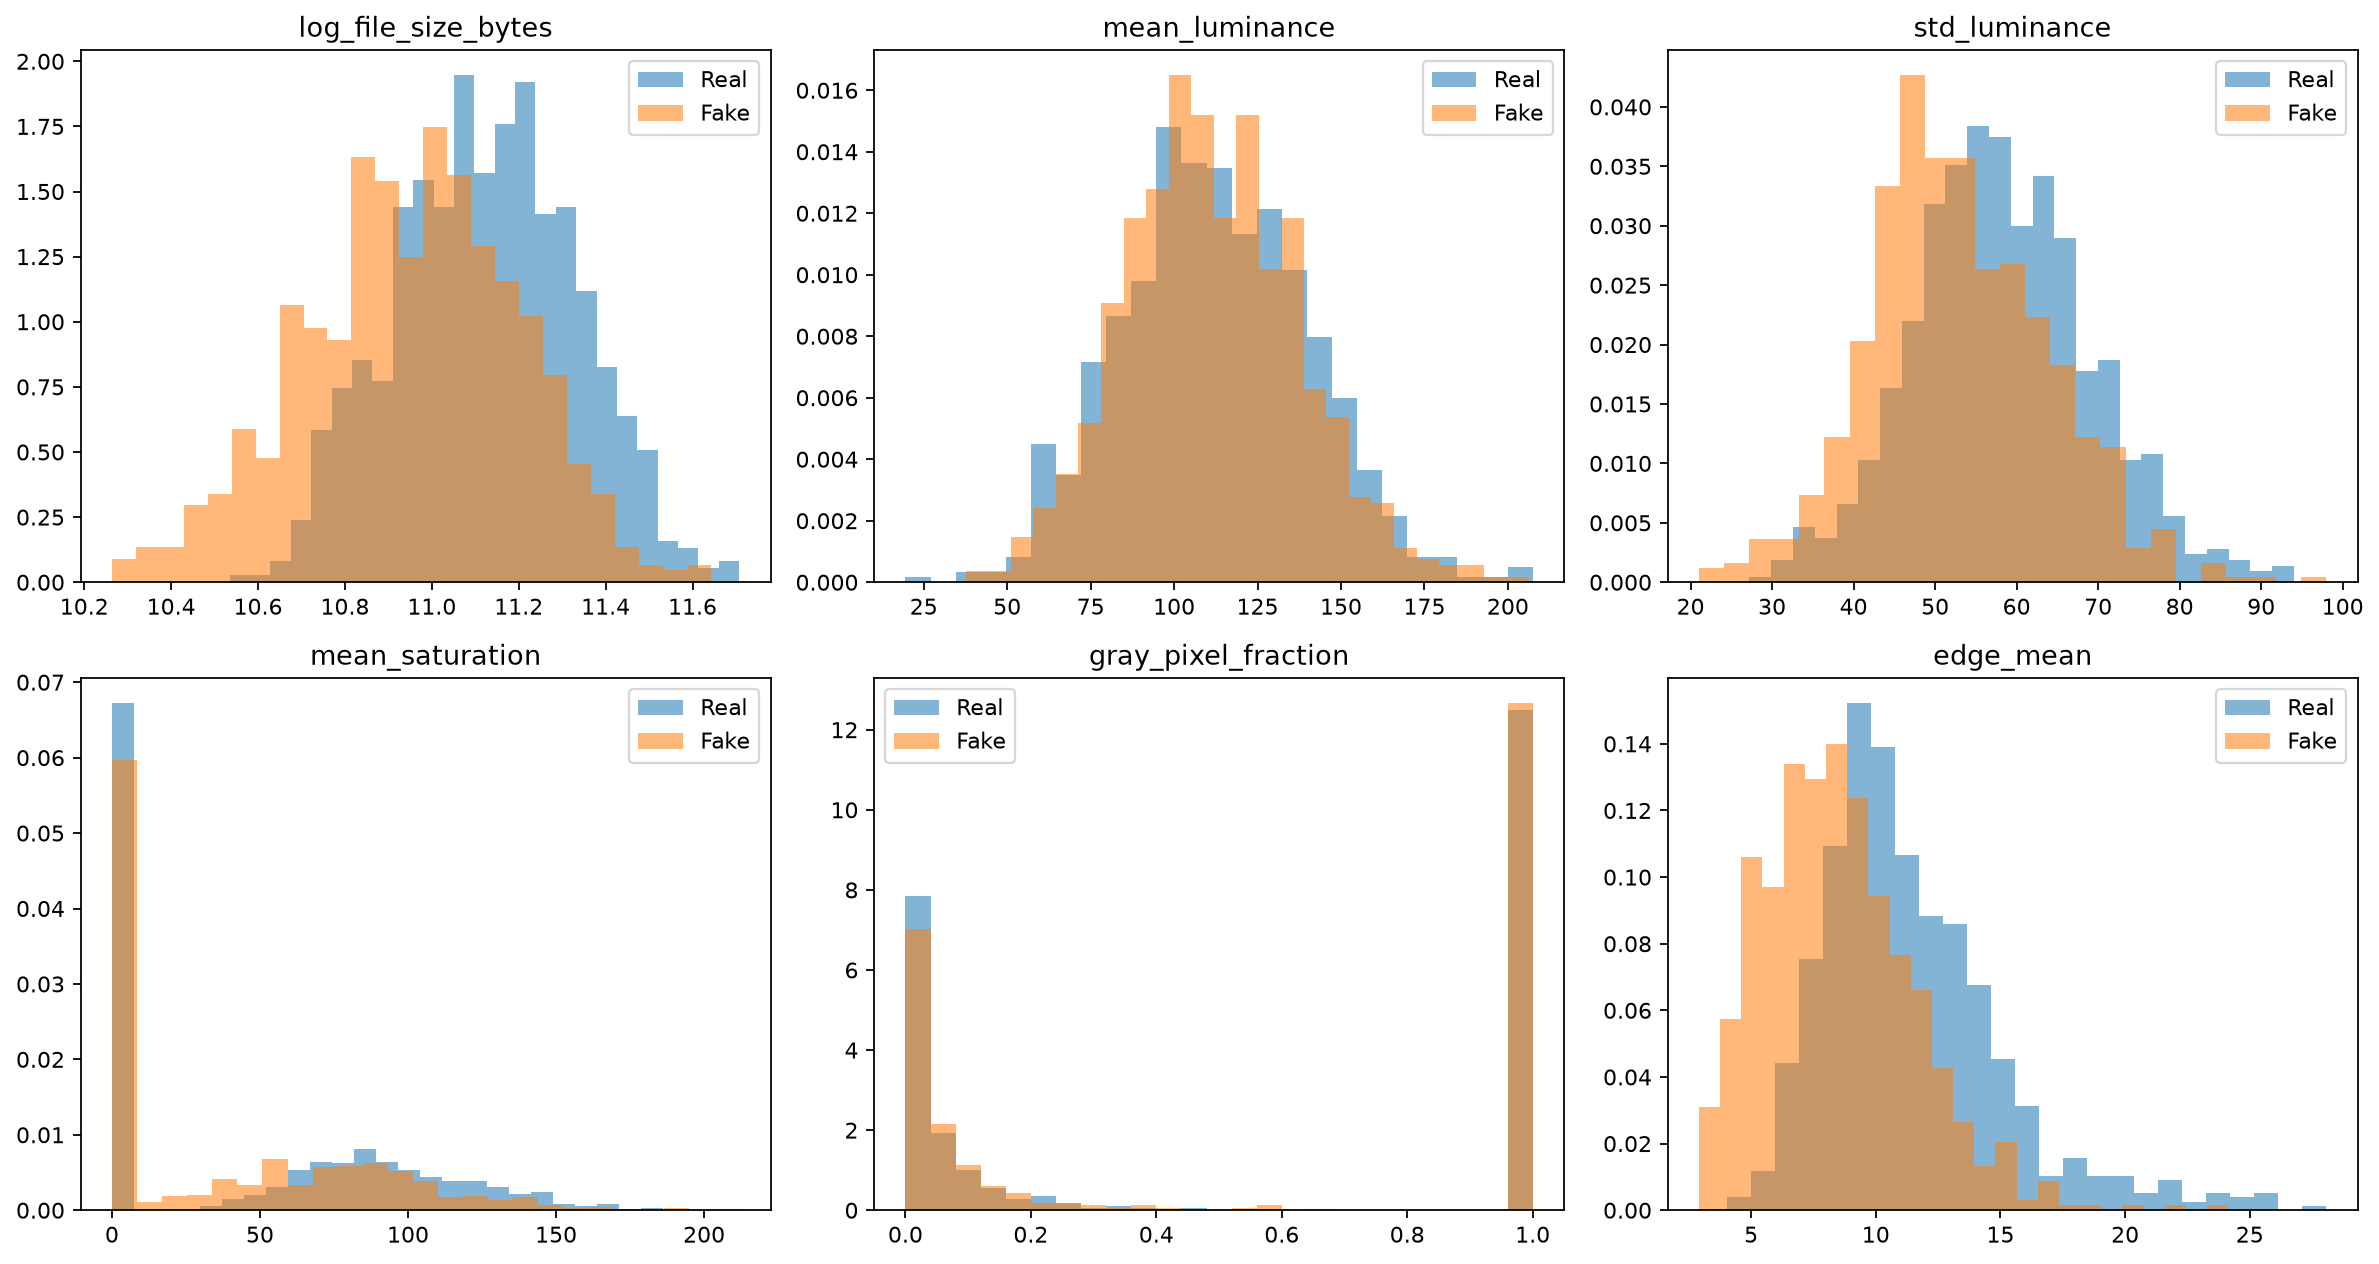

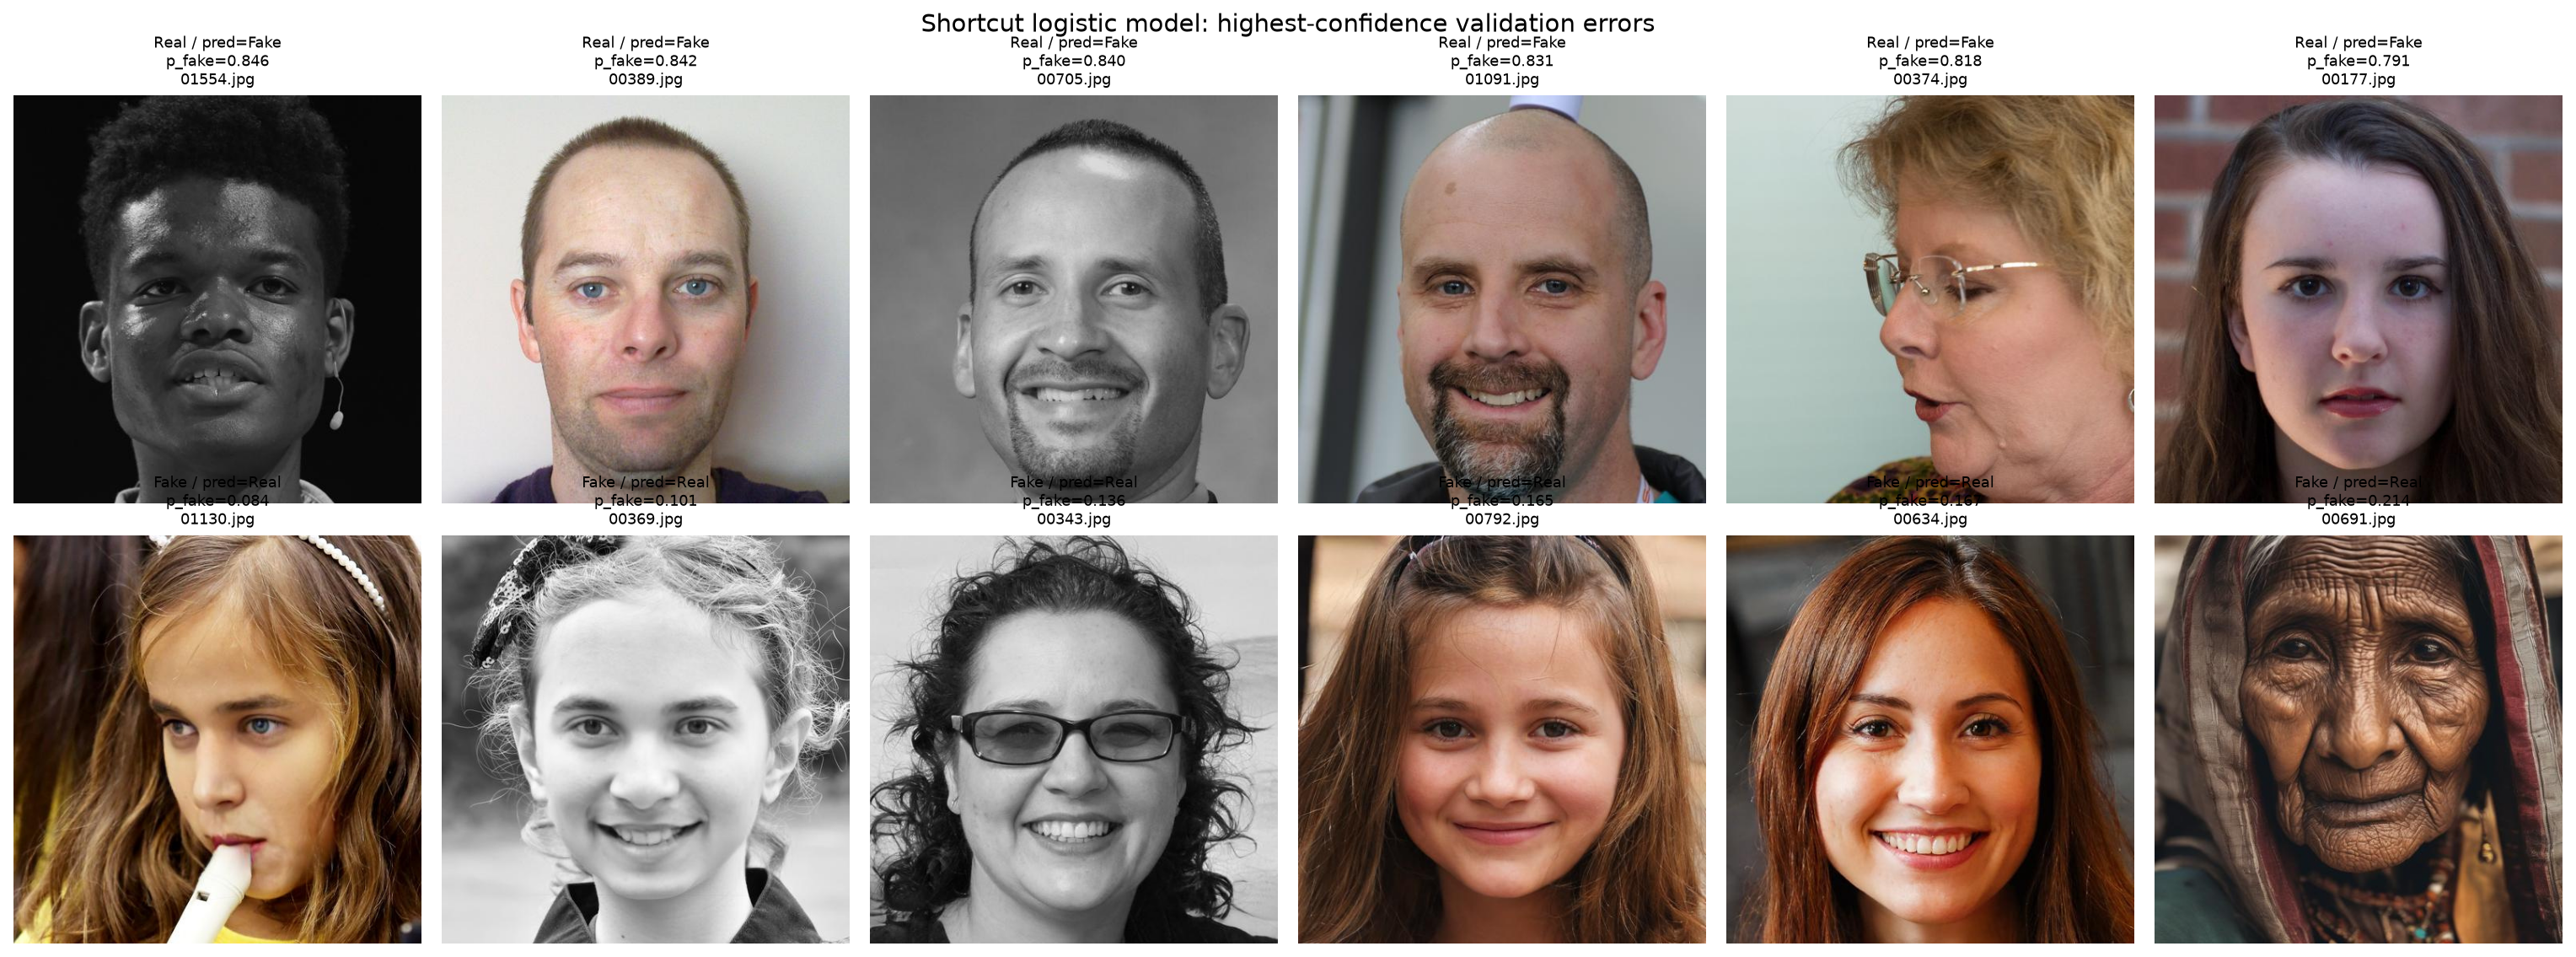

In [4]:
from IPython.display import Image as DisplayImage, display

display(DisplayImage(filename=str(OUTPUT_DIR / 'feature_distributions.png')))
display(DisplayImage(filename=str(OUTPUT_DIR / 'shortcut_error_montage.png')))